Importing all the required modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    make_scorer, roc_curve, precision_recall_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import joblib

Data Collection and Management

In [5]:
exoplanet_df = pd.read_csv('planetsdata.csv')
print(f"Raw data shape: {exoplanet_df.shape}")

Raw data shape: (5569, 118)


In [6]:
exoplanet_df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [7]:
exoplanet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(19)
memory usage: 5.0+ MB


In [8]:
# Drop uncertainty/error columns (not useful for prediction)
cols_to_drop = [col for col in exoplanet_df.columns
                if '_ERROR_MIN' in col or '_ERROR_MAX' in col or '_LIMIT' in col]
exoplanet_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [9]:
unnecessary_columns = [
    # Identifiers & Discovery Data
    "S_NAME", "S_NAME_HD", "S_NAME_HIP", # Names/Catalog IDs
    "P_DETECTION", "P_DISCOVERY_FACILITY",         # How/where it was found
    "P_YEAR", "P_UPDATE",                          # Timeline of discovery
    
    # Celestial Coordinates (Location Metadata)
    "S_RA", "S_DEC", "S_RA_STR", "S_DEC_STR",      # Coordinates (Numbers & Strings)
    "S_RA_TXT", "S_DEC_TXT",                       # Coordinates (Text format)
    
    # Constellation Data (Human Mapping) ---
    "S_CONSTELLATION", "S_CONSTELLATION_ABR", 
    "S_CONSTELLATION_ENG",
    
    # Highly Null or Non-Physical Metadata
    "P_OMEGA",         # Longitude of ascending node (irrelevant for habitability)
    "P_MASS_ORIGIN"    # Method used to calculate mass (Not a physical property)
]

# Apply the drop
exoplanet_df = exoplanet_df.drop(columns=unnecessary_columns, errors='ignore')

print(f"Dropped {len(unnecessary_columns)} metadata and location-based columns.")

Dropped 18 metadata and location-based columns.


In [10]:
# Drop KNOWN LEAKAGE columns
# P_ESI: Earth Similarity Index - directly measures habitability
# P_HABZONE_OPT/CON: Binary flags that DEFINE the target variable
# S_HZ_*: Habitable zone boundaries used to compute P_HABZONE_OPT/CON
# S_ABIO_ZONE, S_SNOW_LINE, S_TIDAL_LOCK: Stellar habitability indicators
# P_DISTANCE_EFF: Effective distance used in HZ boundary calculations
# P_TYPE_TEMP: Categorical (Cold/Warm/Hot) where ALL 69 habitable planets are "Warm" and ZERO Cold/Hot planets are habitable. 
LEAKAGE_COLUMNS = [
    "P_ESI",
    "P_HABZONE_OPT", "P_HABZONE_CON",
    "S_HZ_OPT_MIN", "S_HZ_OPT_MAX",
    "S_HZ_CON_MIN", "S_HZ_CON_MAX",
    "S_HZ_CON0_MIN", "S_HZ_CON0_MAX",
    "S_HZ_CON1_MIN", "S_HZ_CON1_MAX",
    "S_ABIO_ZONE", "S_SNOW_LINE", "S_TIDAL_LOCK",
    "P_DISTANCE_EFF",
    "P_TYPE_TEMP"  # TARGET PROXY — see cross-tab analysis above
]
exoplanet_df.drop(columns=LEAKAGE_COLUMNS, errors='ignore', inplace=True)
print(f"Leakage features removed: {LEAKAGE_COLUMNS}")

Leakage features removed: ['P_ESI', 'P_HABZONE_OPT', 'P_HABZONE_CON', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_ABIO_ZONE', 'S_SNOW_LINE', 'S_TIDAL_LOCK', 'P_DISTANCE_EFF', 'P_TYPE_TEMP']


In [11]:
# Drop redundant MIN/MAX columns
# These are near-identical to their base columns and add noise, not signal
REDUNDANT_COLUMNS = [
    "P_TEMP_EQUIL_MIN", "P_TEMP_EQUIL_MAX",
    "P_TEMP_SURF_MIN", "P_TEMP_SURF_MAX",
    "P_FLUX_MIN", "P_FLUX_MAX",
    "P_ECCENTRICITY_MIN",    # Often equals P_ECCENTRICITY
    "P_INCLINATIONR_MIN",    # Often equals P_INCLINATION
]
exoplanet_df.drop(columns=REDUNDANT_COLUMNS, errors='ignore', inplace=True)
print(f"Redundant features removed: {REDUNDANT_COLUMNS}")

Redundant features removed: ['P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'P_TEMP_SURF_MIN', 'P_TEMP_SURF_MAX', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_ECCENTRICITY_MIN', 'P_INCLINATIONR_MIN']


In [12]:
# Analyze class distribution

# Absolute class counts
class_counts = exoplanet_df['P_HABITABLE'].value_counts()

# Class proportions
class_ratios = exoplanet_df['P_HABITABLE'].value_counts(normalize=True)

print("Class distribution:")
print(class_counts)

print("\nClass ratio:")
print(class_ratios)

Class distribution:
P_HABITABLE
0    5500
2      40
1      29
Name: count, dtype: int64

Class ratio:
P_HABITABLE
0    0.987610
2    0.007183
1    0.005207
Name: proportion, dtype: float64


In [13]:
# Convert multi-class habitability to binary

# Original P_HABITABLE values:
# 0 -> Non-habitable
# 1 -> Potentially habitable (conservative zone)
# 2 -> Potentially habitable (optimistic zone)
# For this project, we merge 1 and 2 into a single
# "Habitable" class to frame a binary classification problem.

exoplanet_df["P_HABITABLE_BINARY"] = exoplanet_df["P_HABITABLE"].apply(
    lambda x: 1 if x in [1, 2] else 0
)

# Verify new class distribution
print("Binary class distribution:")
print(exoplanet_df["P_HABITABLE_BINARY"].value_counts())

print("\nBinary class ratio:")
print(exoplanet_df["P_HABITABLE_BINARY"].value_counts(normalize=True))

Binary class distribution:
P_HABITABLE_BINARY
0    5500
1      69
Name: count, dtype: int64

Binary class ratio:
P_HABITABLE_BINARY
0    0.98761
1    0.01239
Name: proportion, dtype: float64


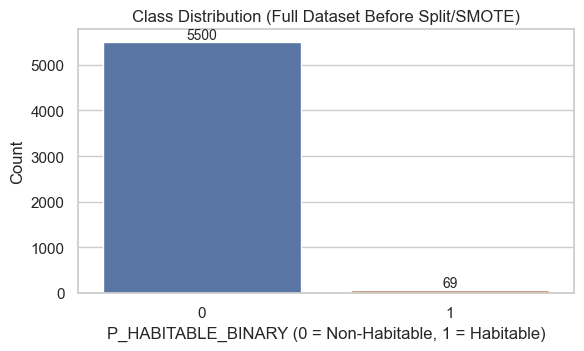

In [14]:
# Visualization: overall class distribution
class_counts_full = exoplanet_df['P_HABITABLE_BINARY'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=class_counts_full.index,
    y=class_counts_full.values,
    palette=['#4C72B0', '#DD8452']
)
ax.set_title('Class Distribution (Full Dataset Before Split/SMOTE)')
ax.set_xlabel('P_HABITABLE_BINARY (0 = Non-Habitable, 1 = Habitable)')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts_full.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [15]:
# Drop original multi-class target (we use binary)
exoplanet_df.drop(columns=["P_HABITABLE"], inplace=True)

Feature Engineering

In [16]:
TARGET = "P_HABITABLE_BINARY"

In [17]:
# Derive star type from temperature (categorical feature engineering)
def derive_detailed_star_type(temp):
    if pd.isna(temp): return None
    if temp > 30000: return 'O-Type'
    if temp > 10000: return 'B-Type'
    if temp > 7500: return 'A-Type'
    if temp > 6000: return 'F-Type'
    if temp > 5000: return 'G-Type'
    if temp > 3500: return 'K-Type'
    if temp > 2500: return 'M-Type'
    if temp > 1500: return 'L-Type'
    if temp > 800: return 'T-Type'
    if temp <= 800: return 'Y-Type'
    return 'Unclassified'

exoplanet_df['Derived_S_TYPE'] = exoplanet_df['S_TEMPERATURE'].apply(derive_detailed_star_type)
exoplanet_df.drop(columns=['S_TYPE'], inplace=True, errors='ignore')

In [18]:
# Identify column types
numerical_cols = exoplanet_df.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_cols = exoplanet_df.select_dtypes(include=['object']).columns.tolist()
if TARGET in numerical_cols: numerical_cols.remove(TARGET)
if 'P_NAME' in categorical_cols: categorical_cols.remove('P_NAME')

In [19]:
# Baseline: 9 curated physical features (guaranteed clean)
BASELINE_FEATURES = [
    "P_RADIUS", "P_MASS", "P_DENSITY", "P_TEMP_SURF",
    "P_PERIOD", "P_SEMI_MAJOR_AXIS",
    "S_TEMPERATURE", "S_LUMINOSITY", "S_METALLICITY"
]

In [20]:
print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {categorical_cols}")
print(f"Baseline features: {BASELINE_FEATURES}")

Numerical features: 27
Categorical features: ['P_TYPE', 'S_TYPE_TEMP', 'Derived_S_TYPE']
Baseline features: ['P_RADIUS', 'P_MASS', 'P_DENSITY', 'P_TEMP_SURF', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'S_TEMPERATURE', 'S_LUMINOSITY', 'S_METALLICITY']


Train - Test Split (Before Preprocessing)

In [21]:
# All preprocessing will happen separately on train and test to prevent any information leakage
X_all = exoplanet_df.drop(columns=[TARGET, 'P_NAME'], errors='ignore')
y = exoplanet_df[TARGET]

In [22]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train_raw.shape[0]} samples, Test: {X_test_raw.shape[0]} samples")
print(f"Train class distribution:\n{y_train.value_counts(normalize=True)}")

Train: 4455 samples, Test: 1114 samples
Train class distribution:
P_HABITABLE_BINARY
0    0.987654
1    0.012346
Name: proportion, dtype: float64


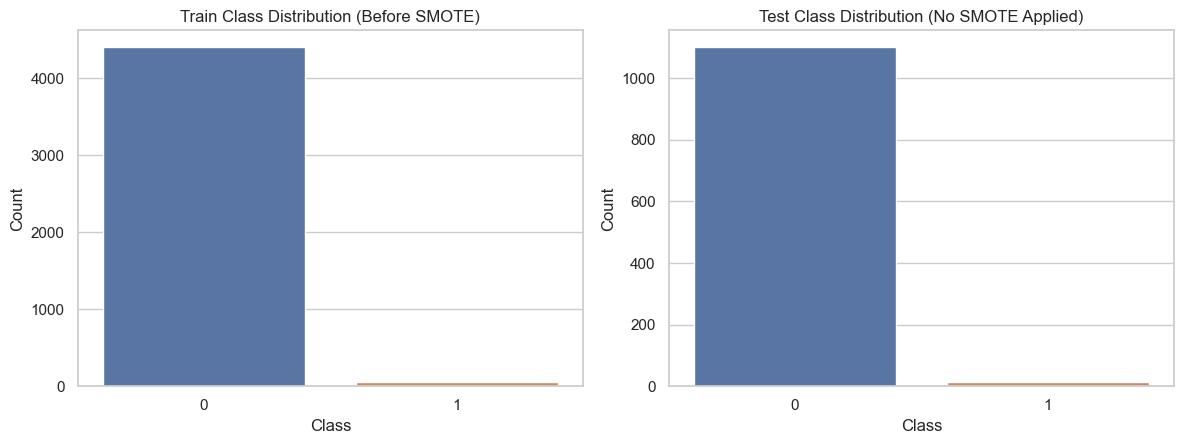

In [23]:
# Visualization: train/test class distribution before SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Train Class Distribution (Before SMOTE)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Test Class Distribution (No SMOTE Applied)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

Data Preprocessing

In [24]:
# Separate numerical and categorical columns from the raw split
num_cols_in_data = [c for c in numerical_cols if c in X_train_raw.columns]
cat_cols_in_data = [c for c in categorical_cols if c in X_train_raw.columns]

In [25]:
# Impute numerical data with median
median_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(
    median_imputer.fit_transform(X_train_raw[num_cols_in_data]),
    columns=num_cols_in_data, index=X_train_raw.index
)
X_test_num = pd.DataFrame(
    median_imputer.transform(X_test_raw[num_cols_in_data]),
    columns=num_cols_in_data, index=X_test_raw.index
)
print(f"Numerical imputation: fit on train ({X_train_num.shape[0]}), transform both")

Numerical imputation: fit on train (4455), transform both


In [26]:
# Store pre-clipping numerical data for outlier visualization
X_train_num_before_clipping = X_train_num.copy()

In [27]:
# Clip outliers using train quantiles
clip_bounds = {}
for col in num_cols_in_data:
    if X_train_num[col].nunique() <= 2:
        continue
    lower = X_train_num[col].quantile(0.05)
    upper = X_train_num[col].quantile(0.95)
    clip_bounds[col] = (lower, upper)
    X_train_num[col] = X_train_num[col].clip(lower, upper)
    X_test_num[col] = X_test_num[col].clip(lower, upper)  # Use TRAIN bounds
print(f"Outlier clipping: {len(clip_bounds)} features clipped using train quantiles")

Outlier clipping: 27 features clipped using train quantiles


In [28]:
# Impute categorical data
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_raw[cat_cols_in_data] = X_train_raw[cat_cols_in_data].replace(
    [None, 'None', 'nan'], np.nan
)
X_test_raw[cat_cols_in_data] = X_test_raw[cat_cols_in_data].replace(
    [None, 'None', 'nan'], np.nan
)
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train_raw[cat_cols_in_data]),
    columns=cat_cols_in_data, index=X_train_raw.index
)
X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test_raw[cat_cols_in_data]),
    columns=cat_cols_in_data, index=X_test_raw.index
)

In [29]:
# Variance threshold 
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_num)
kept_mask = selector.get_support()
kept_num_cols = [c for c, keep in zip(num_cols_in_data, kept_mask) if keep]
dropped_cols = [c for c, keep in zip(num_cols_in_data, kept_mask) if not keep]
print(f"Low variance features removed: {dropped_cols}")

Low variance features removed: ['P_HILL_SPHERE']


In [30]:
X_train_num = X_train_num[kept_num_cols]
X_test_num = X_test_num[kept_num_cols]

In [31]:
# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(X_train_cat)
test_encoded = encoder.transform(X_test_cat)
encoded_cols = encoder.get_feature_names_out()

X_train_encoded = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train_raw.index)
X_test_encoded = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test_raw.index)

In [32]:
# Combine numerical + encoded categorical
X_train_full = pd.concat([X_train_num, X_train_encoded], axis=1)
X_test_full = pd.concat([X_test_num, X_test_encoded], axis=1)

In [33]:
print("\nFinal features used for training:")
print(X_train_full.columns.tolist())
print(f"Total features: {len(X_train_full.columns)}")


Final features used for training:
['P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY', 'P_INCLINATION', 'S_MAG', 'S_DISTANCE', 'S_TEMPERATURE', 'S_MASS', 'S_RADIUS', 'S_METALLICITY', 'S_AGE', 'S_LOG_LUM', 'S_LOG_G', 'P_ESCAPE', 'P_POTENTIAL', 'P_GRAVITY', 'P_DENSITY', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TEMP_SURF', 'S_LUMINOSITY', 'P_TYPE_Jovian', 'P_TYPE_Miniterran', 'P_TYPE_Neptunian', 'P_TYPE_Subterran', 'P_TYPE_Superterran', 'P_TYPE_Terran', 'S_TYPE_TEMP_A', 'S_TYPE_TEMP_B', 'S_TYPE_TEMP_BD', 'S_TYPE_TEMP_F', 'S_TYPE_TEMP_G', 'S_TYPE_TEMP_K', 'S_TYPE_TEMP_M', 'S_TYPE_TEMP_O', 'S_TYPE_TEMP_PSR', 'S_TYPE_TEMP_WD', 'Derived_S_TYPE_A-Type', 'Derived_S_TYPE_B-Type', 'Derived_S_TYPE_F-Type', 'Derived_S_TYPE_G-Type', 'Derived_S_TYPE_K-Type', 'Derived_S_TYPE_L-Type', 'Derived_S_TYPE_M-Type', 'Derived_S_TYPE_O-Type', 'Derived_S_TYPE_Y-Type']
Total features: 51


In [34]:
# Baseline feature sets (subset of numerical)
baseline_available = [c for c in BASELINE_FEATURES if c in kept_num_cols]
X_train_base = X_train_num[baseline_available]
X_test_base = X_test_num[baseline_available]

In [35]:
print(f"\nFinal feature sets:")
print(f"  Baseline: {X_train_base.shape[1]} features")
print(f"  Full:     {X_train_full.shape[1]} features")


Final feature sets:
  Baseline: 9 features
  Full:     51 features


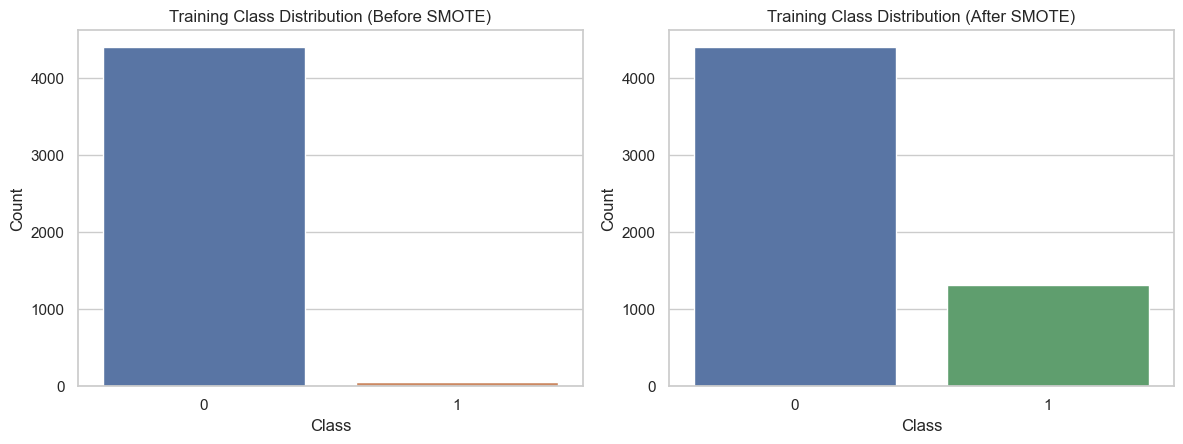

In [36]:
# Visualization: class distribution before vs after SMOTE
smote_for_plot = SMOTE(sampling_strategy=0.3, k_neighbors=5, random_state=42)
_, y_train_smote_plot = smote_for_plot.fit_resample(X_train_full, y_train)

before_smote_counts = y_train.value_counts().sort_index()
after_smote_counts = pd.Series(y_train_smote_plot).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=before_smote_counts.index, y=before_smote_counts.values, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Training Class Distribution (Before SMOTE)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.barplot(x=after_smote_counts.index, y=after_smote_counts.values, ax=axes[1], palette=['#4C72B0', '#55A868'])
axes[1].set_title('Training Class Distribution (After SMOTE)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

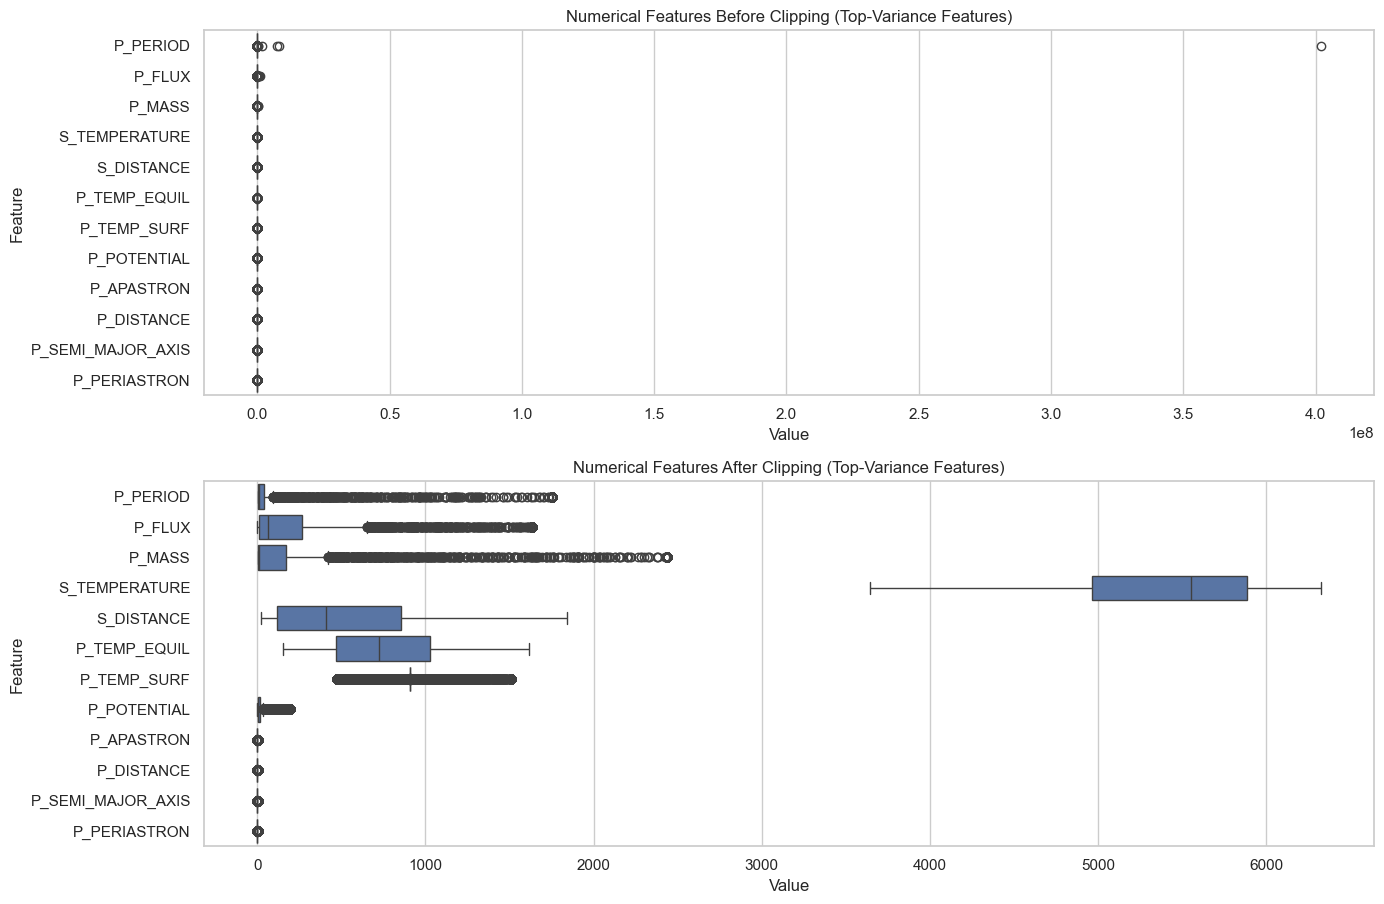

In [37]:
# Visualization: outliers before vs after clipping (boxplots)
top_outlier_cols = X_train_num_before_clipping.std().sort_values(ascending=False).head(12).index.tolist()

if len(top_outlier_cols) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

    sns.boxplot(data=X_train_num_before_clipping[top_outlier_cols], ax=axes[0], orient='h', color='#C44E52')
    axes[0].set_title('Numerical Features Before Clipping (Top-Variance Features)')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Feature')

    sns.boxplot(data=X_train_num[top_outlier_cols], ax=axes[1], orient='h', color='#4C72B0')
    axes[1].set_title('Numerical Features After Clipping (Top-Variance Features)')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Feature')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    plt.close()

Correlation based Leakage Check

In [38]:
train_corrs = X_train_full.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 15 most correlated features with target (training set):")
for feat, val in train_corrs.head(15).items():
    print(f"  {feat}: {val:.4f}")


Top 15 most correlated features with target (training set):
  Derived_S_TYPE_M-Type: 0.2883
  S_TYPE_TEMP_M: 0.2385
  P_TEMP_SURF: 0.2209
  S_LOG_LUM: 0.2064
  S_TEMPERATURE: 0.2008
  S_MASS: 0.1750
  P_TEMP_EQUIL: 0.1485
  S_LOG_G: 0.1400
  S_RADIUS: 0.1249
  Derived_S_TYPE_G-Type: 0.1043
  S_METALLICITY: 0.0884
  S_DISTANCE: 0.0868
  S_TYPE_TEMP_G: 0.0862
  P_RADIUS: 0.0859
  P_TYPE_Superterran: 0.0850


In [39]:
high_corr = train_corrs[train_corrs > 0.8]
if len(high_corr) > 0:
    print(f"\nFeatures with |correlation| > 0.8 detected:")
    for feat, val in high_corr.items():
        print(f"   {feat}: {val:.4f}")
else:
    print("\nNo features with |correlation| > 0.8 — no leakage detected.")


No features with |correlation| > 0.8 — no leakage detected.


In [40]:
moderate_corr = train_corrs[(train_corrs > 0.5) & (train_corrs <= 0.8)]
if len(moderate_corr) > 0:
    print(f"\nFeatures with 0.5 < |correlation| <= 0.8 :")
    for feat, val in moderate_corr.items():
        print(f"   {feat}: {val:.4f}")

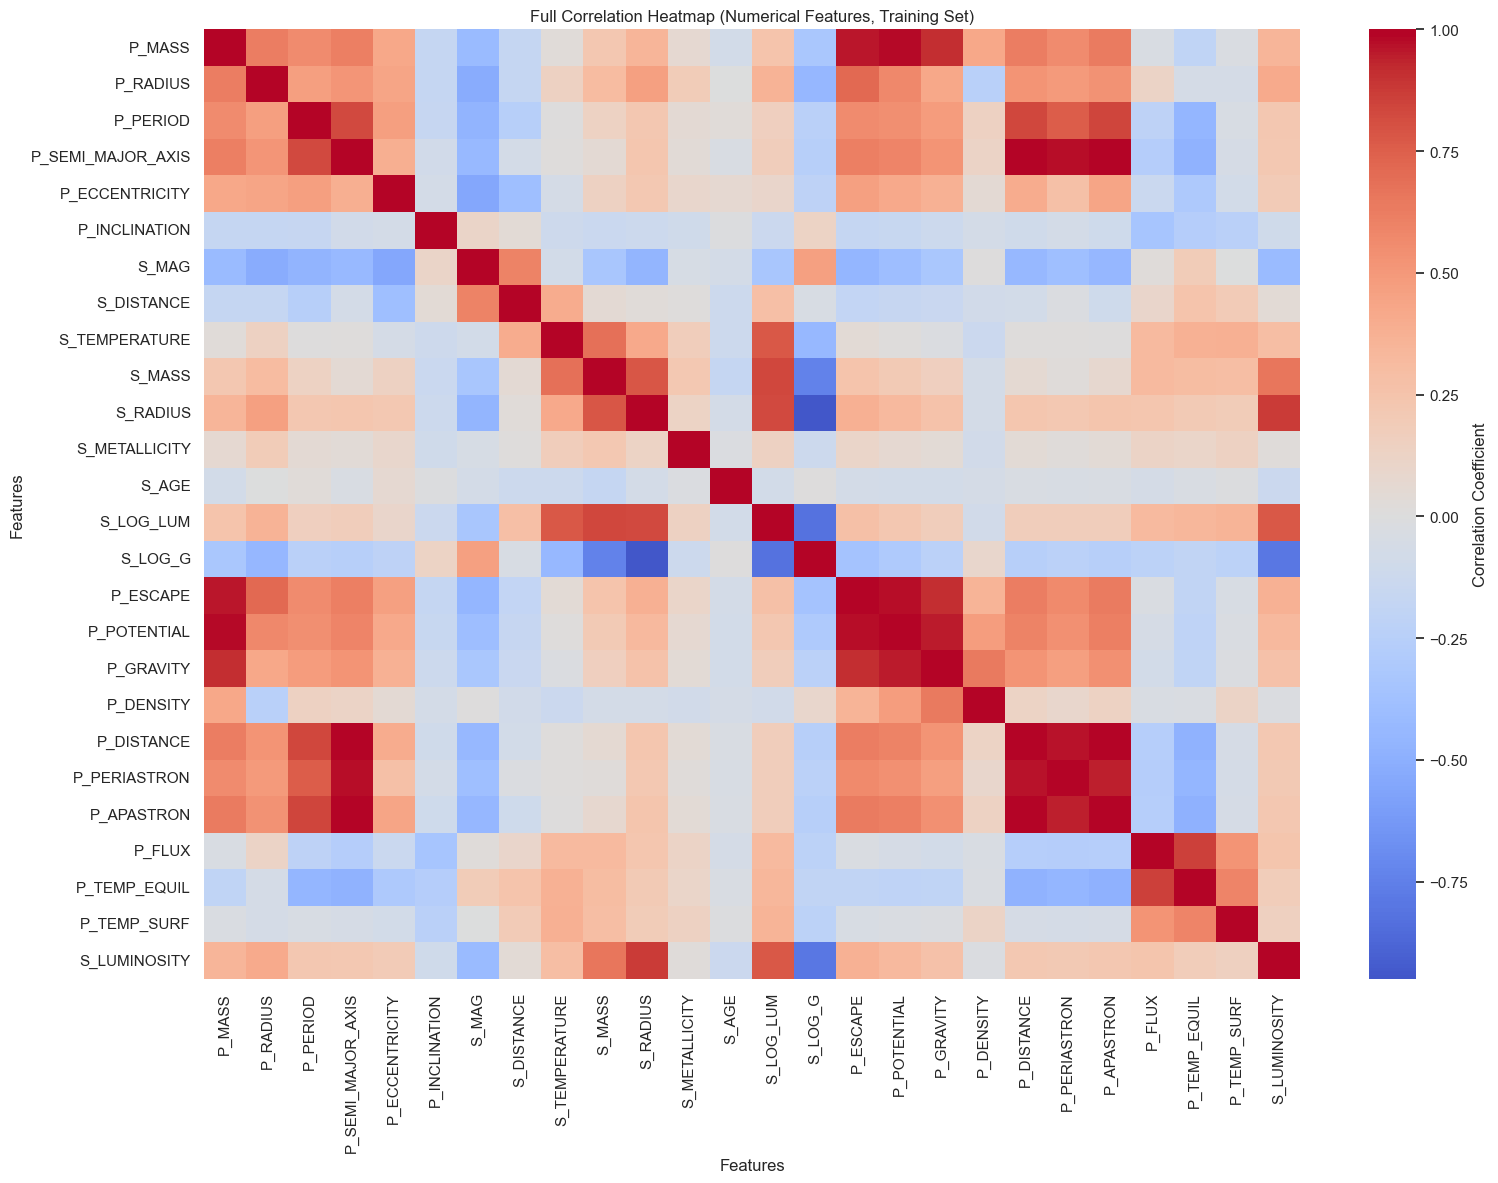

In [41]:
# Visualization: full correlation heatmap for numerical features
if X_train_num.shape[1] > 1:
    corr_matrix_num = X_train_num.corr()
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        corr_matrix_num,
        cmap='coolwarm',
        center=0,
        square=False,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title('Full Correlation Heatmap (Numerical Features, Training Set)')
    plt.xlabel('Features')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    plt.close()

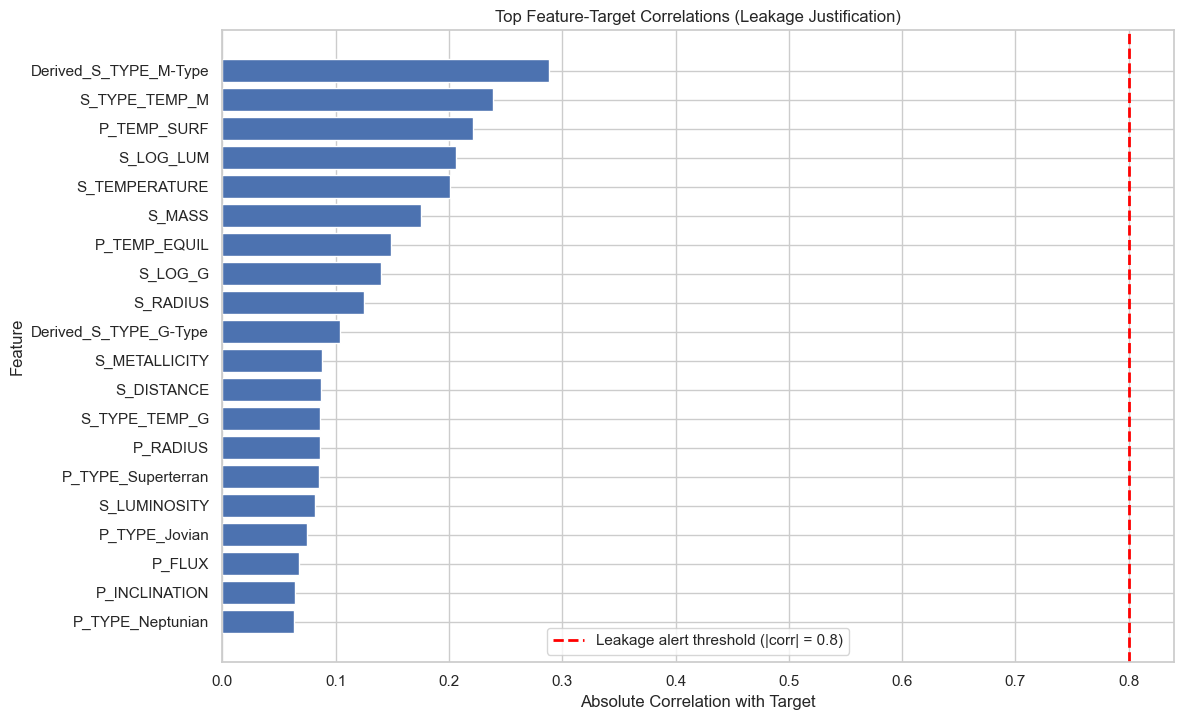

In [42]:
# Visualization: highest feature-target correlations for leakage justification
top_target_corr = train_corrs.head(20).sort_values(ascending=True)
colors = ['#C44E52' if v > 0.8 else '#4C72B0' for v in top_target_corr.values]

plt.figure(figsize=(12, 8))
plt.barh(top_target_corr.index, top_target_corr.values, color=colors)
plt.axvline(0.8, color='red', linestyle='--', linewidth=2, label='Leakage alert threshold (|corr| = 0.8)')
plt.title('Top Feature-Target Correlations (Leakage Justification)')
plt.xlabel('Absolute Correlation with Target')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

Defining model pipelines

In [43]:
def make_pipelines(use_smote=True):
    """Create pipelines for all 4 classifiers.
    Architecture: Scaler → SMOTE → Classifier
    - Scaler inside pipeline prevents test-set statistic leakage
    - SMOTE inside pipeline ensures synthetic samples only from train folds
    """
    smote_step = [("smote", SMOTE(
        sampling_strategy=0.3, k_neighbors=5, random_state=42
    ))] if use_smote else []

    pipelines = {
        "Logistic Regression": ImbPipeline(steps=[
            ("scaler", StandardScaler()),
        ] + smote_step + [
            ("classifier", LogisticRegression(
                class_weight=None if use_smote else {0: 1, 1: 6},
                C=0.3, solver="liblinear", max_iter=1000, random_state=42
            ))
        ]),
        "Random Forest": ImbPipeline(steps=[
            ("scaler", StandardScaler()),
        ] + smote_step + [
            ("classifier", RandomForestClassifier(
                n_estimators=400, max_depth=8, min_samples_leaf=10,
                class_weight=None if use_smote else "balanced_subsample",
                random_state=42, n_jobs=-1
            ))
        ]),
        "SVM (RBF Kernel)": ImbPipeline(steps=[
            ("scaler", StandardScaler()),
        ] + smote_step + [
            ("classifier", SVC(
                kernel="rbf", C=1.0, gamma="scale",
                class_weight=None if use_smote else "balanced",
                probability=True, random_state=42
            ))
        ]),
        "XGBoost": ImbPipeline(steps=[
            ("scaler", StandardScaler()),
        ] + smote_step + [
            ("classifier", xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="auc",
                learning_rate=0.05, max_depth=4, subsample=0.7,
                colsample_bytree=0.7, min_child_weight=10,
                gamma=0.5, reg_alpha=1.0, reg_lambda=2.0,
                scale_pos_weight=1 if use_smote else 80,
                n_estimators=200, random_state=42,
                use_label_encoder=False, verbosity=0
            ))
        ]),
    }
    return pipelines

Model Evaluation

In [44]:
model_eval_curves = []

def evaluate_model(pipeline, X_train, X_test, y_train, y_test, model_name, feature_set):
    """Train pipeline, evaluate on train AND test to detect overfitting."""
    pipeline.fit(X_train, y_train)

    # Test set metrics (primary evaluation)
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)
    y_pred_tuned = (y_prob_test >= 0.3).astype(int)

    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test, zero_division=0)
    test_rec = recall_score(y_test, y_pred_test, zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, zero_division=0)
    test_roc = roc_auc_score(y_test, y_prob_test)
    test_pr_auc = average_precision_score(y_test, y_prob_test)

    # Train set metrics (for overfitting check)
    y_prob_train = pipeline.predict_proba(X_train)[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    train_acc = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
    train_roc = roc_auc_score(y_train, y_prob_train)

    # Overfitting diagnostic
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    roc_gap = train_roc - test_roc

    print(f"\n--- {model_name} | {feature_set} ---")
    print(f"  Confusion Matrix (threshold=0.5):")
    cm = confusion_matrix(y_test, y_pred_test)
    print(f"    {cm}")
    print(f"  TEST  -> Acc: {test_acc:.4f}  Prec: {test_prec:.4f}  Rec: {test_rec:.4f}  F1: {test_f1:.4f}")
    print(f"           ROC-AUC: {test_roc:.4f}  PR-AUC: {test_pr_auc:.4f}")
    print(f"  TRAIN -> Acc: {train_acc:.4f}  F1: {train_f1:.4f}  ROC-AUC: {train_roc:.4f}")
    print(f"  GAP (Train-Test) -> Acc: {acc_gap:+.4f}  F1: {f1_gap:+.4f}  ROC-AUC: {roc_gap:+.4f}")

    if acc_gap > 0.10:
        print(f"Large accuracy gap ({acc_gap:.4f}) — possible overfitting")
    elif test_roc < 0.60:
        print(f"Low ROC-AUC ({test_roc:.4f}) — possible underfitting")
    else:
        print(f"No significant overfitting or underfitting detected")

    # Tuned threshold
    acc_t = accuracy_score(y_test, y_pred_tuned)
    prec_t = precision_score(y_test, y_pred_tuned, zero_division=0)
    rec_t = recall_score(y_test, y_pred_tuned, zero_division=0)
    f1_t = f1_score(y_test, y_pred_tuned, zero_division=0)
    print(f"  [Tuned t=0.3] Acc: {acc_t:.4f}  Prec: {prec_t:.4f}  Rec: {rec_t:.4f}  F1: {f1_t:.4f}")

    model_eval_curves.append({
        "Model": model_name,
        "Feature Set": feature_set,
        "y_true": y_test.copy(),
        "y_prob": y_prob_test.copy(),
        "y_pred": y_pred_test.copy(),
        "ROC-AUC": test_roc,
        "PR-AUC": test_pr_auc,
    })

    return {
        "Model": model_name, "Feature Set": feature_set,
        "Train_Acc": round(train_acc, 4), "Test_Acc": round(test_acc, 4),
        "Acc_Gap": round(acc_gap, 4),
        "Precision": round(test_prec, 4), "Recall": round(test_rec, 4),
        "F1": round(test_f1, 4),
        "ROC-AUC": round(test_roc, 4), "PR-AUC": round(test_pr_auc, 4),
    }, pipeline

Training and evaluating all models

In [45]:
all_results = []
trained_models = {}

In [46]:
# BASELINE MODELS (9 features)
baseline_pipelines = make_pipelines(use_smote=True)
for name, pipe in baseline_pipelines.items():
    metrics, fitted = evaluate_model(
        pipe, X_train_base, X_test_base, y_train, y_test,
        name, "Baseline"
    )
    all_results.append(metrics)
    trained_models[f"{name}_baseline"] = fitted


--- Logistic Regression | Baseline ---
  Confusion Matrix (threshold=0.5):
    [[1044   56]
 [   0   14]]
  TEST  -> Acc: 0.9497  Prec: 0.2000  Rec: 1.0000  F1: 0.3333
           ROC-AUC: 0.9871  PR-AUC: 0.3862
  TRAIN -> Acc: 0.9473  F1: 0.3188  ROC-AUC: 0.9861
  GAP (Train-Test) -> Acc: -0.0025  F1: -0.0145  ROC-AUC: -0.0010
No significant overfitting or underfitting detected
  [Tuned t=0.3] Acc: 0.9336  Prec: 0.1591  Rec: 1.0000  F1: 0.2745

--- Random Forest | Baseline ---
  Confusion Matrix (threshold=0.5):
    [[1080   20]
 [   0   14]]
  TEST  -> Acc: 0.9820  Prec: 0.4118  Rec: 1.0000  F1: 0.5833
           ROC-AUC: 0.9968  PR-AUC: 0.7097
  TRAIN -> Acc: 0.9870  F1: 0.6548  ROC-AUC: 0.9991
  GAP (Train-Test) -> Acc: +0.0049  F1: +0.0714  ROC-AUC: +0.0023
No significant overfitting or underfitting detected
  [Tuned t=0.3] Acc: 0.9704  Prec: 0.2979  Rec: 1.0000  F1: 0.4590

--- SVM (RBF Kernel) | Baseline ---
  Confusion Matrix (threshold=0.5):
    [[1074   26]
 [   0   14]]
  TE

In [47]:
#FULL CLEANED MODELS
full_pipelines = make_pipelines(use_smote=True)
for name, pipe in full_pipelines.items():
    metrics, fitted = evaluate_model(
        pipe, X_train_full, X_test_full, y_train, y_test,
        name, "Full (cleaned)"
    )
    all_results.append(metrics)
    trained_models[f"{name}_full"] = fitted


--- Logistic Regression | Full (cleaned) ---
  Confusion Matrix (threshold=0.5):
    [[1075   25]
 [   0   14]]
  TEST  -> Acc: 0.9776  Prec: 0.3590  Rec: 1.0000  F1: 0.5283
           ROC-AUC: 0.9952  PR-AUC: 0.6215
  TRAIN -> Acc: 0.9760  F1: 0.5069  ROC-AUC: 0.9974
  GAP (Train-Test) -> Acc: -0.0016  F1: -0.0214  ROC-AUC: +0.0022
No significant overfitting or underfitting detected
  [Tuned t=0.3] Acc: 0.9605  Prec: 0.2414  Rec: 1.0000  F1: 0.3889

--- Random Forest | Full (cleaned) ---
  Confusion Matrix (threshold=0.5):
    [[1098    2]
 [   0   14]]
  TEST  -> Acc: 0.9982  Prec: 0.8750  Rec: 1.0000  F1: 0.9333
           ROC-AUC: 0.9999  PR-AUC: 0.9911
  TRAIN -> Acc: 0.9984  F1: 0.9402  ROC-AUC: 1.0000
  GAP (Train-Test) -> Acc: +0.0002  F1: +0.0068  ROC-AUC: +0.0001
No significant overfitting or underfitting detected
  [Tuned t=0.3] Acc: 0.9964  Prec: 0.7778  Rec: 1.0000  F1: 0.8750

--- SVM (RBF Kernel) | Full (cleaned) ---
  Confusion Matrix (threshold=0.5):
    [[1090   10]


In [48]:
results_df = pd.DataFrame(all_results)
results_df

,Model,Feature Set,Train_Acc,Test_Acc,Acc_Gap,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,Baseline,0.9473,0.9497,-0.0025,0.2000,1.0000,0.3333,0.9871,0.3862
1,Random Forest,Baseline,0.9870,0.9820,0.0049,0.4118,1.0000,0.5833,0.9968,0.7097
2,SVM (RBF Kernel),Baseline,0.9767,0.9767,-0.0000,0.3500,1.0000,0.5185,0.9956,0.6589
3,XGBoost,Baseline,0.9886,0.9820,0.0065,0.4118,1.0000,0.5833,0.9969,0.7598
4,Logistic Regression,Full (cleaned),0.9760,0.9776,-0.0016,0.3590,1.0000,0.5283,0.9952,0.6215
5,Random Forest,Full (cleaned),0.9984,0.9982,0.0002,0.8750,1.0000,0.9333,0.9999,0.9911
6,SVM (RBF Kernel),Full (cleaned),0.9921,0.9883,0.0038,0.5238,0.7857,0.6286,0.9956,0.6861
7,XGBoost,Full (cleaned),0.9978,0.9964,0.0013,0.7778,1.0000,0.8750,0.9994,0.9528


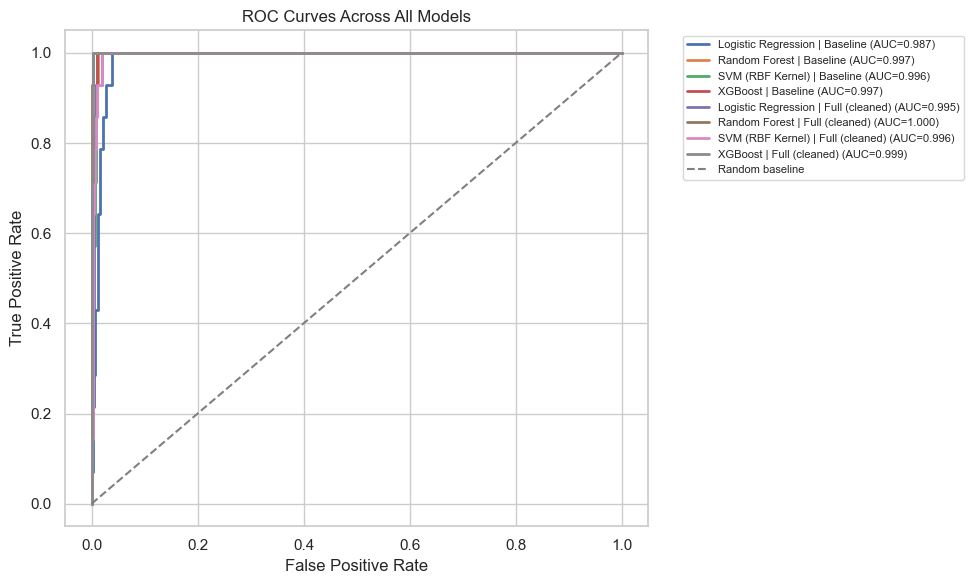

In [49]:
# Visualization: ROC Curves for all evaluated models
plt.figure(figsize=(10, 6))
for item in model_eval_curves:
    fpr, tpr, _ = roc_curve(item["y_true"], item["y_prob"])
    label = f"{item['Model']} | {item['Feature Set']} (AUC={item['ROC-AUC']:.3f})"
    plt.plot(fpr, tpr, linewidth=2, label=label)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.title('ROC Curves Across All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

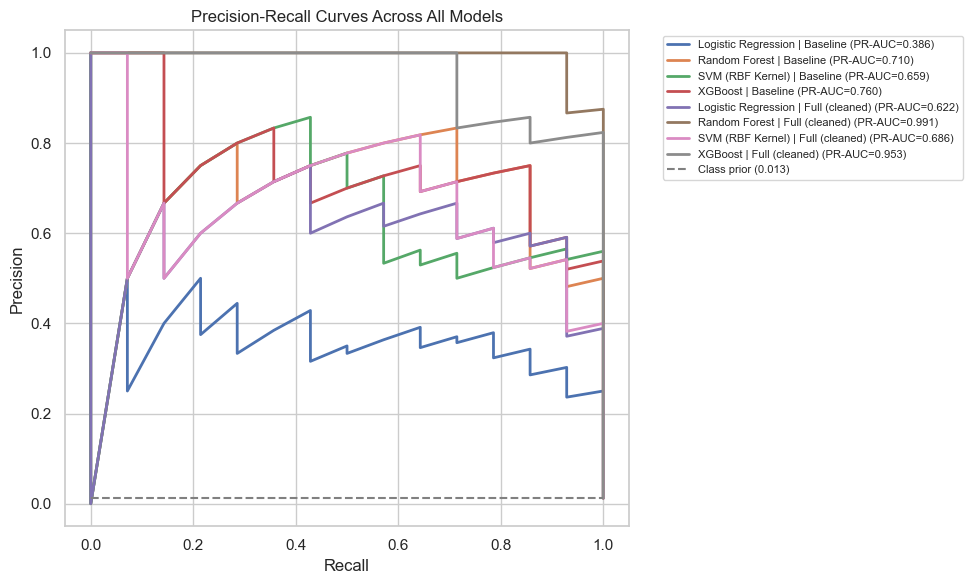

In [50]:
# Visualization: Precision-Recall Curves for all evaluated models
plt.figure(figsize=(10, 6))
positive_prior = y_test.mean()
for item in model_eval_curves:
    precision, recall, _ = precision_recall_curve(item["y_true"], item["y_prob"])
    label = f"{item['Model']} | {item['Feature Set']} (PR-AUC={item['PR-AUC']:.3f})"
    plt.plot(recall, precision, linewidth=2, label=label)

plt.hlines(positive_prior, 0, 1, linestyle='--', color='gray', label=f'Class prior ({positive_prior:.3f})')
plt.title('Precision-Recall Curves Across All Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

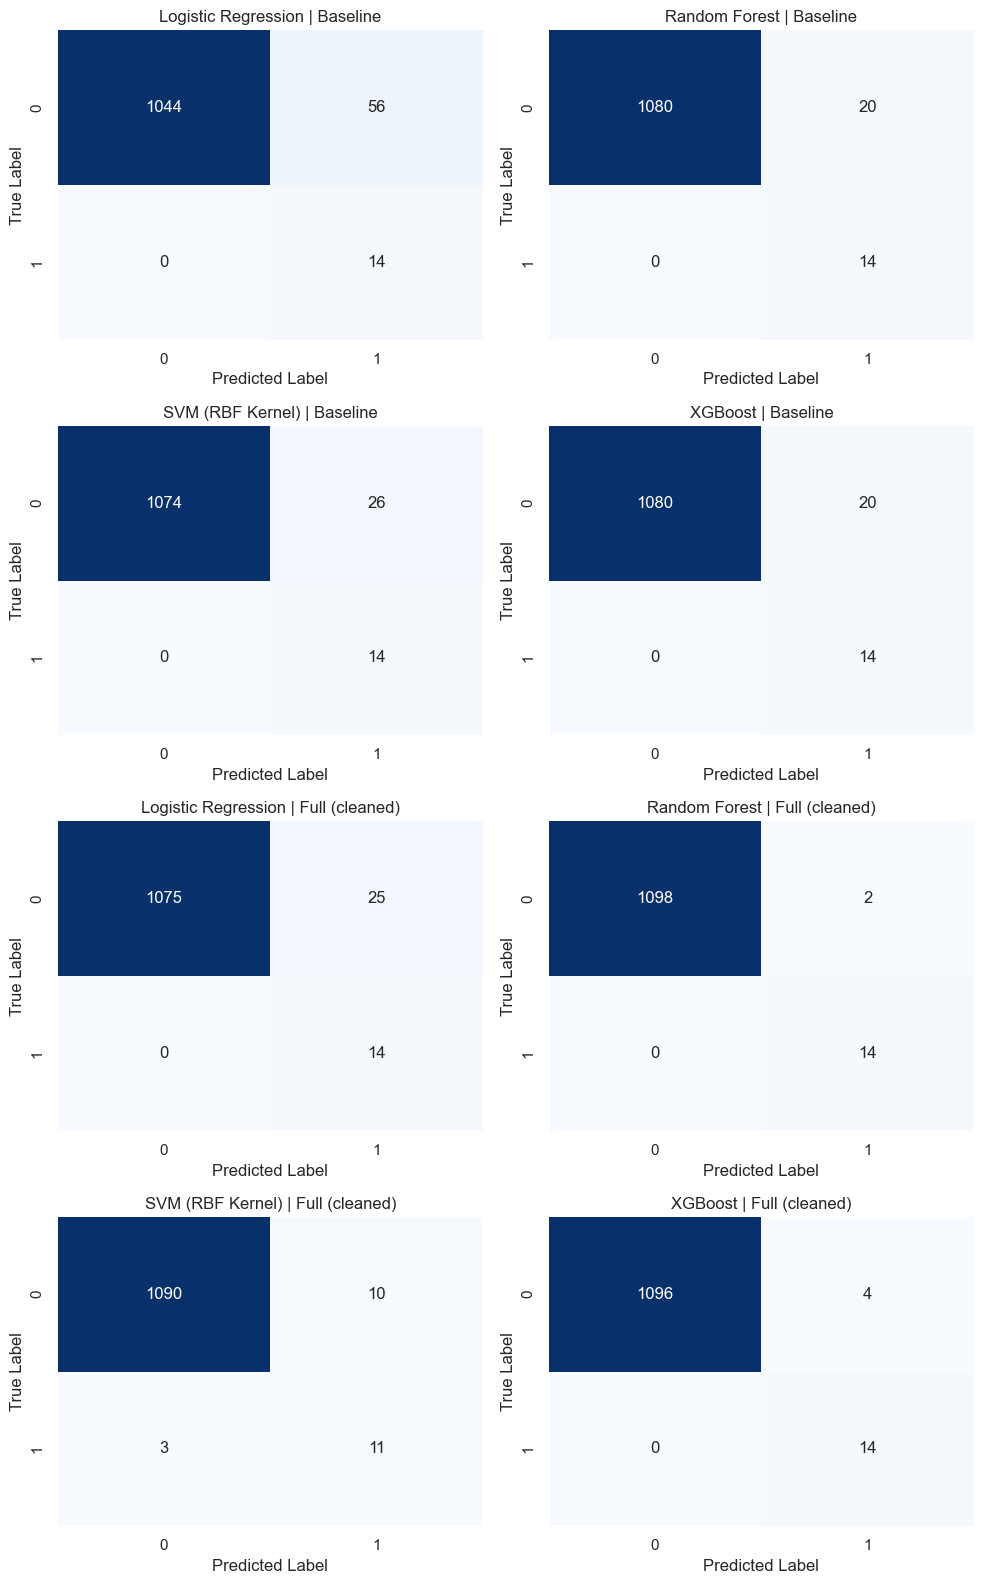

In [51]:
# Visualization: Confusion matrices (heatmap) for all evaluated models
n_models = len(model_eval_curves)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, item in enumerate(model_eval_curves):
    cm = confusion_matrix(item["y_true"], item["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f"{item['Model']} | {item['Feature Set']}")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
plt.close()

Cross-validation (5-fold stratified)

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [53]:
# Run CV on the best-performing model type from each feature set
cv_models = {
    "Random Forest (Baseline)": (make_pipelines()["Random Forest"], X_train_base, y_train),
    "XGBoost (Baseline)": (make_pipelines()["XGBoost"], X_train_base, y_train),
    "Random Forest (Full)": (make_pipelines()["Random Forest"], X_train_full, y_train),
    "XGBoost (Full)": (make_pipelines()["XGBoost"], X_train_full, y_train),
}

In [54]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
}

In [55]:
cv_results = []
cv_plot_records = []

In [56]:
for name, (pipe, X_cv, y_cv) in cv_models.items():
    print(f"\n{name}")
    scores = cross_validate(pipe, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)

    mean_acc = scores['test_accuracy'].mean()
    std_acc = scores['test_accuracy'].std()
    mean_f1 = scores['test_f1'].mean()
    std_f1 = scores['test_f1'].std()
    mean_roc = scores['test_roc_auc'].mean()
    std_roc = scores['test_roc_auc'].std()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()

    print(f"  Accuracy:  {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  F1-Score:  {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"  ROC-AUC:   {mean_roc:.4f} ± {std_roc:.4f}")
    print(f"  Precision: {mean_prec:.4f}  Recall: {mean_rec:.4f}")
    print(f"  Per-fold Accuracy: {scores['test_accuracy'].round(4)}")

    # Check for high variance across folds (sign of instability)
    if std_acc > 0.05:
        print(f" High variance across folds — model may be unstable")
    else:
        print(f" Consistent performance across folds")

    cv_results.append({
        "Model": name,
        "CV_Acc": f"{mean_acc:.4f} ± {std_acc:.4f}",
        "CV_F1": f"{mean_f1:.4f} ± {std_f1:.4f}",
        "CV_ROC-AUC": f"{mean_roc:.4f} ± {std_roc:.4f}",
    })

    cv_plot_records.append({
        "Model": name,
        "fold_accuracy": scores['test_accuracy'].copy(),
        "mean_accuracy": mean_acc,
        "std_accuracy": std_acc,
    })


Random Forest (Baseline)
  Accuracy:  0.9793 ± 0.0055
  F1-Score:  0.5120 ± 0.1014
  ROC-AUC:   0.9926 ± 0.0032
  Precision: 0.3675  Recall: 0.8545
  Per-fold Accuracy: [0.9854 0.9731 0.9865 0.9764 0.9753]
 Consistent performance across folds

XGBoost (Baseline)
  Accuracy:  0.9811 ± 0.0040
  F1-Score:  0.5325 ± 0.0732
  ROC-AUC:   0.9930 ± 0.0024
  Precision: 0.3882  Recall: 0.8545
  Per-fold Accuracy: [0.9877 0.9798 0.982  0.9809 0.9753]
 Consistent performance across folds

Random Forest (Full)
  Accuracy:  0.9971 ± 0.0011
  F1-Score:  0.8837 ± 0.0452
  ROC-AUC:   0.9995 ± 0.0006
  Precision: 0.8792  Recall: 0.9091
  Per-fold Accuracy: [0.9978 0.9966 0.9989 0.9966 0.9955]
 Consistent performance across folds

XGBoost (Full)
  Accuracy:  0.9978 ± 0.0014
  F1-Score:  0.9177 ± 0.0489
  ROC-AUC:   0.9991 ± 0.0014
  Precision: 0.8669  Recall: 0.9818
  Per-fold Accuracy: [0.9978 1.     0.9978 0.9978 0.9955]
 Consistent performance across folds


In [57]:
print("\nCross-Validation Summary")
cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))


Cross-Validation Summary
                   Model          CV_Acc           CV_F1      CV_ROC-AUC
Random Forest (Baseline) 0.9793 ± 0.0055 0.5120 ± 0.1014 0.9926 ± 0.0032
      XGBoost (Baseline) 0.9811 ± 0.0040 0.5325 ± 0.0732 0.9930 ± 0.0024
    Random Forest (Full) 0.9971 ± 0.0011 0.8837 ± 0.0452 0.9995 ± 0.0006
          XGBoost (Full) 0.9978 ± 0.0014 0.9177 ± 0.0489 0.9991 ± 0.0014


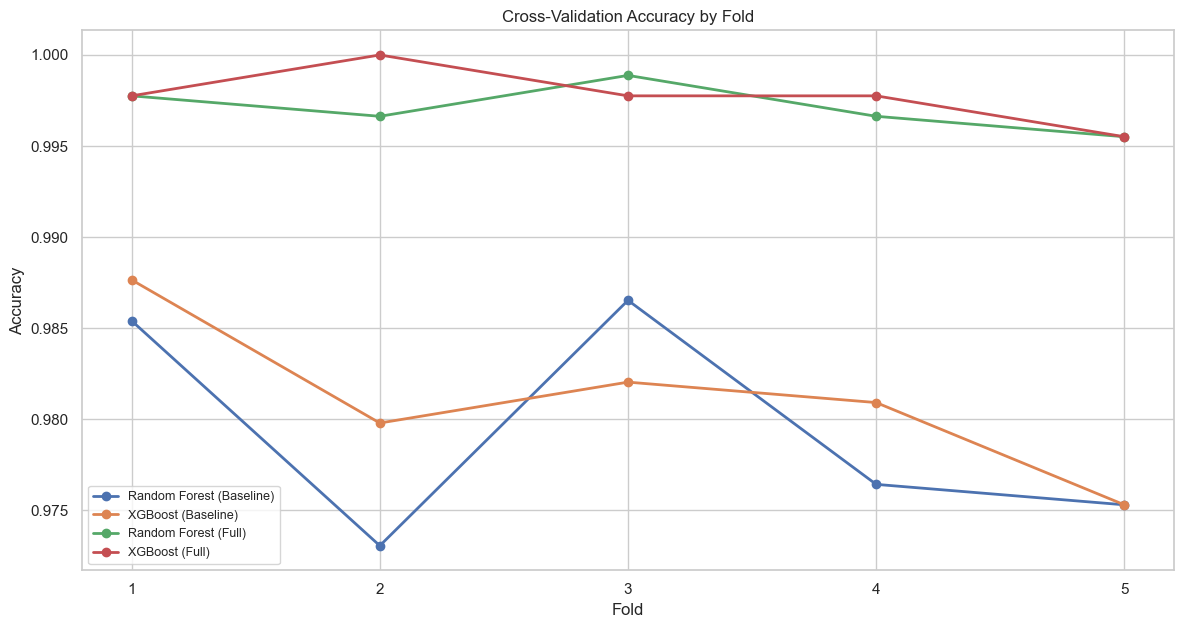

In [58]:
# Visualization: cross-validation fold performance
plt.figure(figsize=(12, 7))
for record in cv_plot_records:
    folds = np.arange(1, len(record["fold_accuracy"]) + 1)
    plt.plot(folds, record["fold_accuracy"], marker='o', linewidth=2, label=record["Model"])

plt.title('Cross-Validation Accuracy by Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, 6, 1))
plt.legend(loc='best', fontsize=9)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

Feature Importance (Random Forest - Full Cleaned)

In [59]:
rf_full = trained_models["Random Forest_full"]
rf_clf = rf_full.named_steps['classifier']
importances = rf_clf.feature_importances_
feature_names = X_train_full.columns

In [60]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

In [61]:
print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))


Top 15 most important features:
          Feature  Importance
      P_TEMP_SURF    0.219398
           P_FLUX    0.170420
     P_TEMP_EQUIL    0.131292
         S_RADIUS    0.058060
          S_LOG_G    0.046473
        S_LOG_LUM    0.036793
     S_LUMINOSITY    0.031880
         P_RADIUS    0.031079
    S_TYPE_TEMP_M    0.029056
         P_PERIOD    0.026478
           S_MASS    0.024355
    S_TEMPERATURE    0.024118
       P_DISTANCE    0.016377
P_SEMI_MAJOR_AXIS    0.016166
           P_MASS    0.015477


In [62]:
# Verify no single feature dominates (which would suggest leakage)
top_importance = importance_df.iloc[0]['Importance']
if top_importance > 0.5:
    print(f"\nTop feature has {top_importance:.2%} importance — investigate for leakage")
else:
    print(f"\nFeature importance is well-distributed (top={top_importance:.2%})")


Feature importance is well-distributed (top=21.94%)


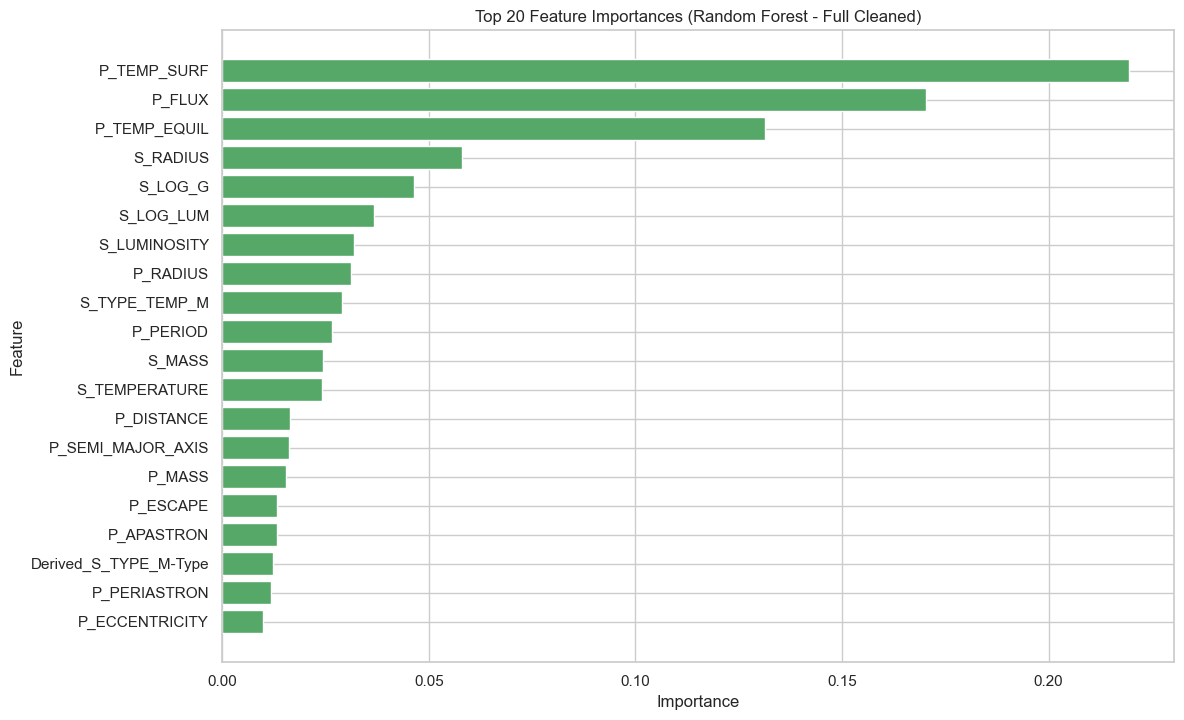

In [63]:
# Visualization: top feature importance bar plot
top_imp = importance_df.head(20).sort_values('Importance', ascending=True)
plt.figure(figsize=(12, 8))
plt.barh(top_imp['Feature'], top_imp['Importance'], color='#55A868')
plt.title('Top 20 Feature Importances (Random Forest - Full Cleaned)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

Results Comparison

In [64]:
comparison_df = pd.DataFrame(all_results)
print("\n" + comparison_df.to_string(index=False))


              Model    Feature Set  Train_Acc  Test_Acc  Acc_Gap  Precision  Recall     F1  ROC-AUC  PR-AUC
Logistic Regression       Baseline     0.9473    0.9497  -0.0025     0.2000  1.0000 0.3333   0.9871  0.3862
      Random Forest       Baseline     0.9870    0.9820   0.0049     0.4118  1.0000 0.5833   0.9968  0.7097
   SVM (RBF Kernel)       Baseline     0.9767    0.9767  -0.0000     0.3500  1.0000 0.5185   0.9956  0.6589
            XGBoost       Baseline     0.9886    0.9820   0.0065     0.4118  1.0000 0.5833   0.9969  0.7598
Logistic Regression Full (cleaned)     0.9760    0.9776  -0.0016     0.3590  1.0000 0.5283   0.9952  0.6215
      Random Forest Full (cleaned)     0.9984    0.9982   0.0002     0.8750  1.0000 0.9333   0.9999  0.9911
   SVM (RBF Kernel) Full (cleaned)     0.9921    0.9883   0.0038     0.5238  0.7857 0.6286   0.9956  0.6861
            XGBoost Full (cleaned)     0.9978    0.9964   0.0013     0.7778  1.0000 0.8750   0.9994  0.9528


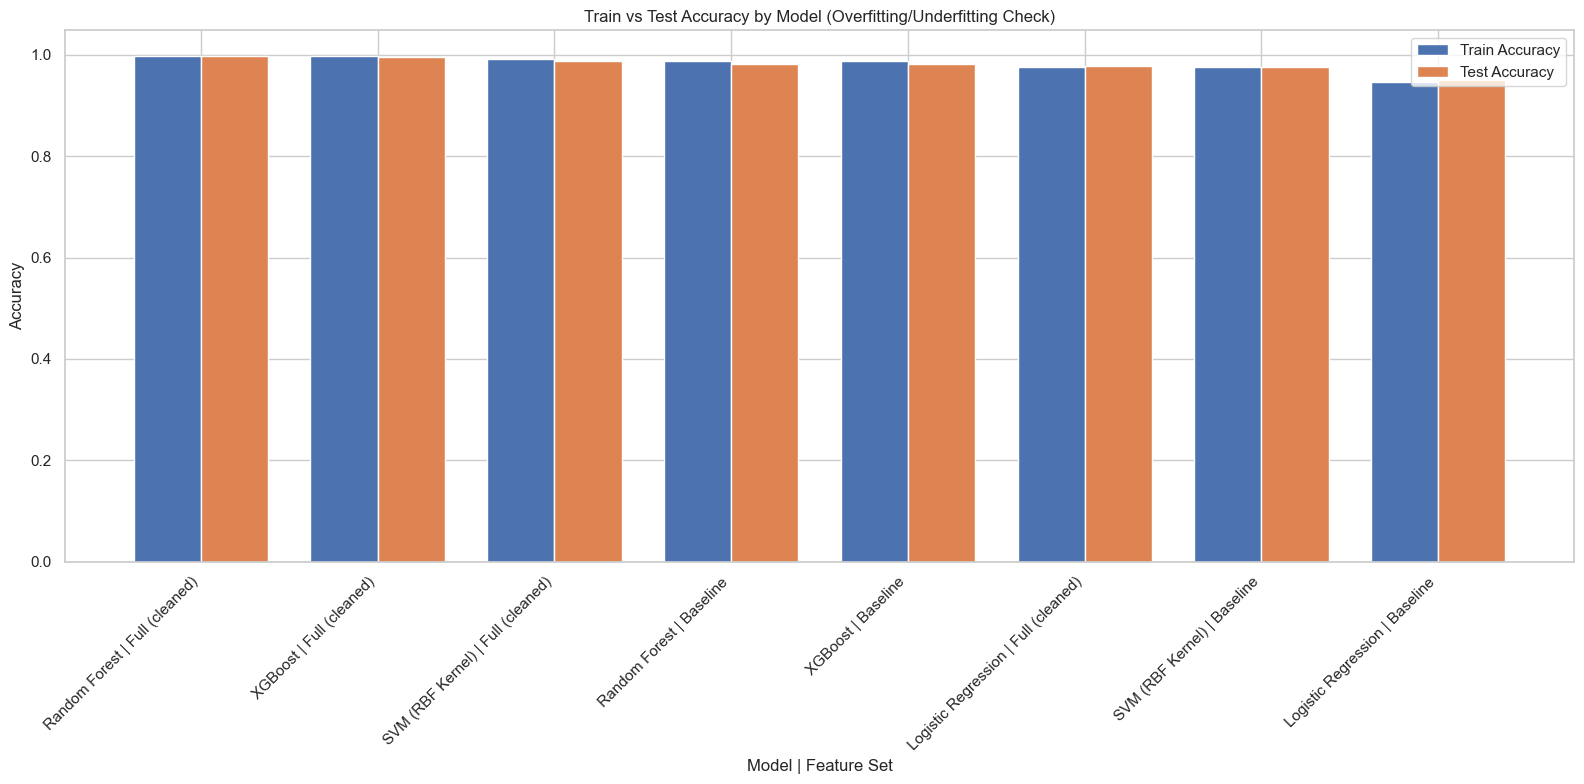

In [65]:
# Visualization: train vs test accuracy comparison (overfitting check)
comparison_plot_df = comparison_df.copy()
comparison_plot_df['Model_Label'] = comparison_plot_df['Model'] + ' | ' + comparison_plot_df['Feature Set']
comparison_plot_df = comparison_plot_df.sort_values('Test_Acc', ascending=False)

x = np.arange(len(comparison_plot_df))
width = 0.38

plt.figure(figsize=(16, 8))
plt.bar(x - width / 2, comparison_plot_df['Train_Acc'], width, label='Train Accuracy', color='#4C72B0')
plt.bar(x + width / 2, comparison_plot_df['Test_Acc'], width, label='Test Accuracy', color='#DD8452')
plt.xticks(x, comparison_plot_df['Model_Label'], rotation=45, ha='right')
plt.title('Train vs Test Accuracy by Model (Overfitting/Underfitting Check)')
plt.xlabel('Model | Feature Set')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

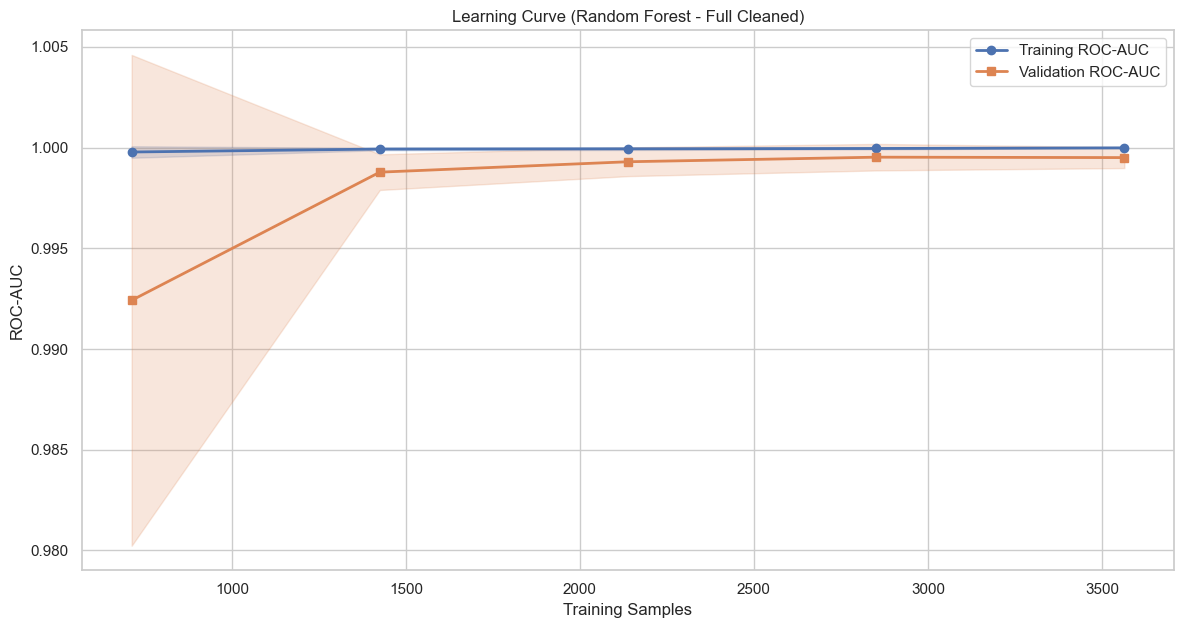

In [66]:
# Visualization: learning curve for generalization (Random Forest - Full)
learning_curve_model = make_pipelines(use_smote=True)["Random Forest"]
train_sizes, train_scores, val_scores = learning_curve(
    learning_curve_model,
    X_train_full,
    y_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(12, 7))
plt.plot(train_sizes, train_mean, marker='o', linewidth=2, color='#4C72B0', label='Training ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='#4C72B0', alpha=0.2)

plt.plot(train_sizes, val_mean, marker='s', linewidth=2, color='#DD8452', label='Validation ROC-AUC')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color='#DD8452', alpha=0.2)

plt.title('Learning Curve (Random Forest - Full Cleaned)')
plt.xlabel('Training Samples')
plt.ylabel('ROC-AUC')
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

Save the best model

In [67]:
best_pipeline = trained_models["Random Forest_full"]
joblib.dump(best_pipeline, "backend/artifacts/habitability_pipeline.pkl")

['backend/artifacts/habitability_pipeline.pkl']